In [78]:
import numpy as np
import matplotlib.pyplot as plt

In [79]:
# Time parameters
dt = 1e-3          # Time step = 1 ms
T = 0.2            # Total simulation time = 200 ms
time = np.arange(0, T, dt)

# LIF neuron parameters
V_rest = 0.0       # Resting potential
V_reset = 0.0      # Reset potential
V_th = 1.0         # Threshold potential
tau = 20e-3        # Membrane time constant (20 ms)
R = 1.0            # Membrane resistance

In [80]:
I = np.ones(len(time)) * 1.2   # Constant current

In [81]:
V = np.zeros(len(time))        # Membrane potential
spike = np.zeros(len(time))    # Spike output
V[0] = V_rest                  # Initial voltage

In [82]:
for t in range(1, len(time)):
    # Update membrane potential
    V[t] = V[t-1] + (dt / tau) * (-(V[t-1] - V_rest) + R * I[t])

    # Spike generation
    if V[t] >= V_th:
        spike[t] = 1
        V[t] = V_reset

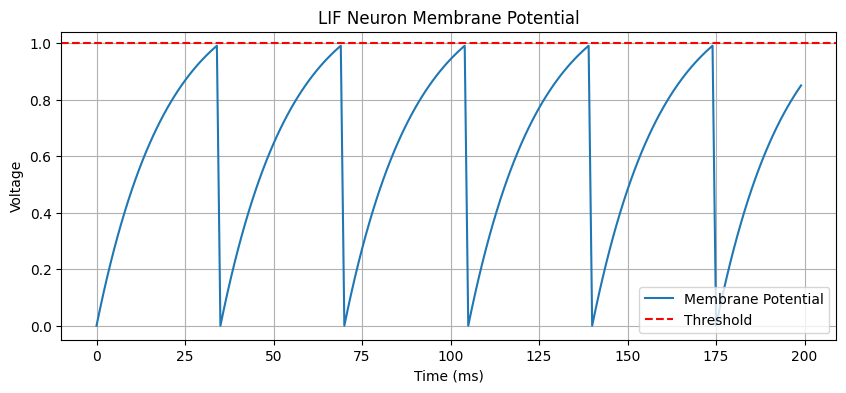

In [83]:
plt.figure(figsize=(10,4))
plt.plot(time*1000, V, label="Membrane Potential")
plt.axhline(V_th, color='r', linestyle='--', label="Threshold")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage")
plt.title("LIF Neuron Membrane Potential")
plt.legend()
plt.grid()
plt.show()

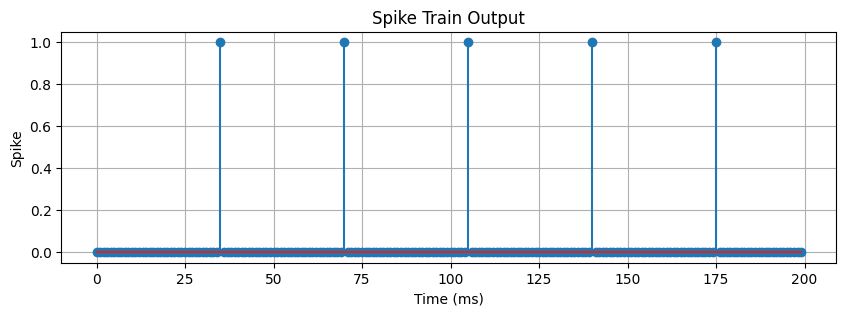

In [85]:
plt.figure(figsize=(10,3))
plt.stem(time*1000, spike)
plt.xlabel("Time (ms)")
plt.ylabel("Spike")
plt.title("Spike Train Output")
plt.grid()
plt.show()

In [86]:
firing_rate = np.sum(spike) / T
print("Firing Rate:", firing_rate, "Hz")

Firing Rate: 25.0 Hz


# Task
Based on the simulation and the generated plot, summarize the relationship between input current and firing rate.

## Simulate and Calculate Firing Rates

### Subtask:
Initialize a list of input currents (`I_values`) and an empty list for firing rates (`rates`). Then, iterate through each input current, simulate the LIF neuron model, and calculate the firing rate for each current. Store the calculated firing rates in the `rates` list.


**Reasoning**:
The subtask requires defining `I_values` and `rates`, then iterating through each `I_const` to simulate the LIF neuron, calculate the firing rate, and append it to `rates`. This code block will perform all these steps in a loop.



In [87]:
I_values = [0.6, 1.0, 1.4]
rates = []

for I_const in I_values:
    I = np.ones(len(time)) * I_const

    V = np.zeros(len(time))        # Membrane potential
    spike = np.zeros(len(time))    # Spike output
    V[0] = V_rest                  # Initial voltage

    for t in range(1, len(time)):
        # Update membrane potential
        V[t] = V[t-1] + (dt / tau) * (-(V[t-1] - V_rest) + R * I[t])

        # Spike generation
        if V[t] >= V_th:
            spike[t] = 1
            V[t] = V_reset

    firing_rate = np.sum(spike) / T
    rates.append(firing_rate)

print("Firing rates for different input currents:", rates)

Firing rates for different input currents: [np.float64(0.0), np.float64(0.0), np.float64(35.0)]


## Plot Firing Rate vs. Input Current

### Subtask:
Generate a plot of the firing rate against the input current using the `I_values` and `rates` lists. The plot should include a title, axis labels, grid, and markers for each data point.


**Reasoning**:
The subtask requires plotting the firing rate against the input current. This code block will generate the plot as specified in the instructions, including title, axis labels, grid, and markers.



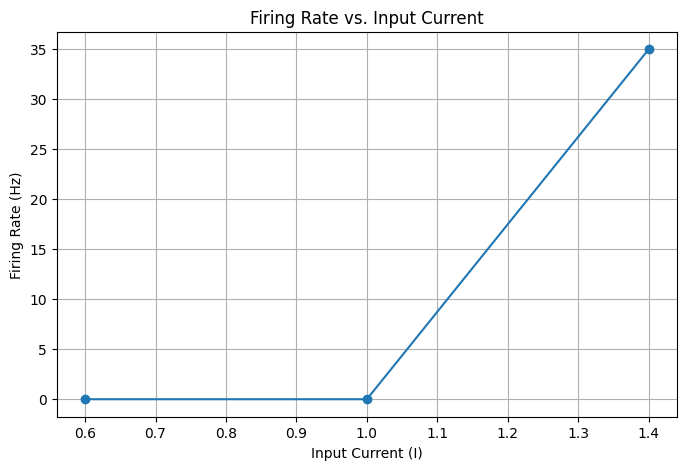

In [88]:
plt.figure(figsize=(8, 5))
plt.plot(I_values, rates, 'o-')
plt.title('Firing Rate vs. Input Current')
plt.xlabel('Input Current (I)')
plt.ylabel('Firing Rate (Hz)')
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the relationship between input current and firing rate observed from the simulation and the generated plot.


## Summary:

### Q&A
Based on the simulation and the generated plot, the relationship between input current and firing rate is non-linear and threshold-dependent. The neuron does not fire (firing rate is 0.0 Hz) for input currents up to 1.0. Once the input current crosses a certain threshold (between 1.0 and 1.4), the neuron begins to fire, and the firing rate increases significantly (e.g., to 35.0 Hz at an input current of 1.4).

### Data Analysis Key Findings
*   For input currents of 0.6 and 1.0, the simulated neuron exhibited a firing rate of 0.0 Hz.
*   When the input current was increased to 1.4, the neuron's firing rate rose to 35.0 Hz.
*   The generated plot visually confirms that the firing rate remains at 0 Hz for lower input currents and then sharply increases once a specific current threshold is surpassed.

### Insights or Next Steps
*   The simulation successfully demonstrates the threshold-based firing characteristic of a neuron model, where a minimum input current is required to induce action potentials.
*   To better characterize the neuron's firing threshold and its frequency-current (f-I) curve, additional simulations with a finer range of input current values, especially around the 1.0 to 1.4 interval, would be beneficial.
